In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('smartcart_customers.csv')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
data.shape


(2240, 22)

In [5]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### 1.Handel Missing Values

In [6]:
data["Income"] = data["Income"].fillna(data["Income"].median())


In [7]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### Feature Engineering

In [8]:
#AGE
data["Age"] = 2026-data["Year_Birth"]

In [9]:
#customer joining date
data["Dt_Customer"]= pd.to_datetime(data["Dt_Customer"], format='%d-%m-%Y',dayfirst=True)
refrence_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = (refrence_date - data["Dt_Customer"]).dt.days

In [10]:
data["total_spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]
data["total_children"] = data["Kidhome"] + data["Teenhome"]

In [11]:
data["Education"].replace({"Basic": "Undergraduate", "2n Cycle": "Undergraduate", "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate"}, inplace=True)

C:\Users\Rohit\AppData\Local\Temp\ipykernel_25960\757772219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Education"].replace({"Basic": "Undergraduate", "2n Cycle": "Undergraduate", "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate"}, inplace=True)


In [12]:
data["living_with"] = data["Marital_Status"].replace({"Alone": "Alone", "Absurd": "Alone", "YOLO": "Alone", "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Married": "Partner", "Together": "Partner"})

### Drop columns 

In [13]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,total_children,living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [14]:
cols=["Marital_Status","ID","Kidhome","Teenhome","Year_Birth","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop=cols+spending_cols
df_cleaned = data.drop(columns=cols_to_drop)

In [15]:
df_cleaned.info

<bound method DataFrame.info of          Education   Income  Recency  NumDealsPurchases  NumWebPurchases  \
0         Graduate  58138.0       58                  3                8   
1         Graduate  46344.0       38                  2                1   
2         Graduate  71613.0       26                  1                8   
3         Graduate  26646.0       26                  2                2   
4     Postgraduate  58293.0       94                  5                5   
...            ...      ...      ...                ...              ...   
2235      Graduate  61223.0       46                  2                9   
2236  Postgraduate  64014.0       56                  7                8   
2237      Graduate  56981.0       91                  1                2   
2238  Postgraduate  69245.0        8                  2                6   
2239  Postgraduate  52869.0       40                  3                3   

      NumCatalogPurchases  NumStorePurchases  NumWebVis

### Outlier Detection and Removal 

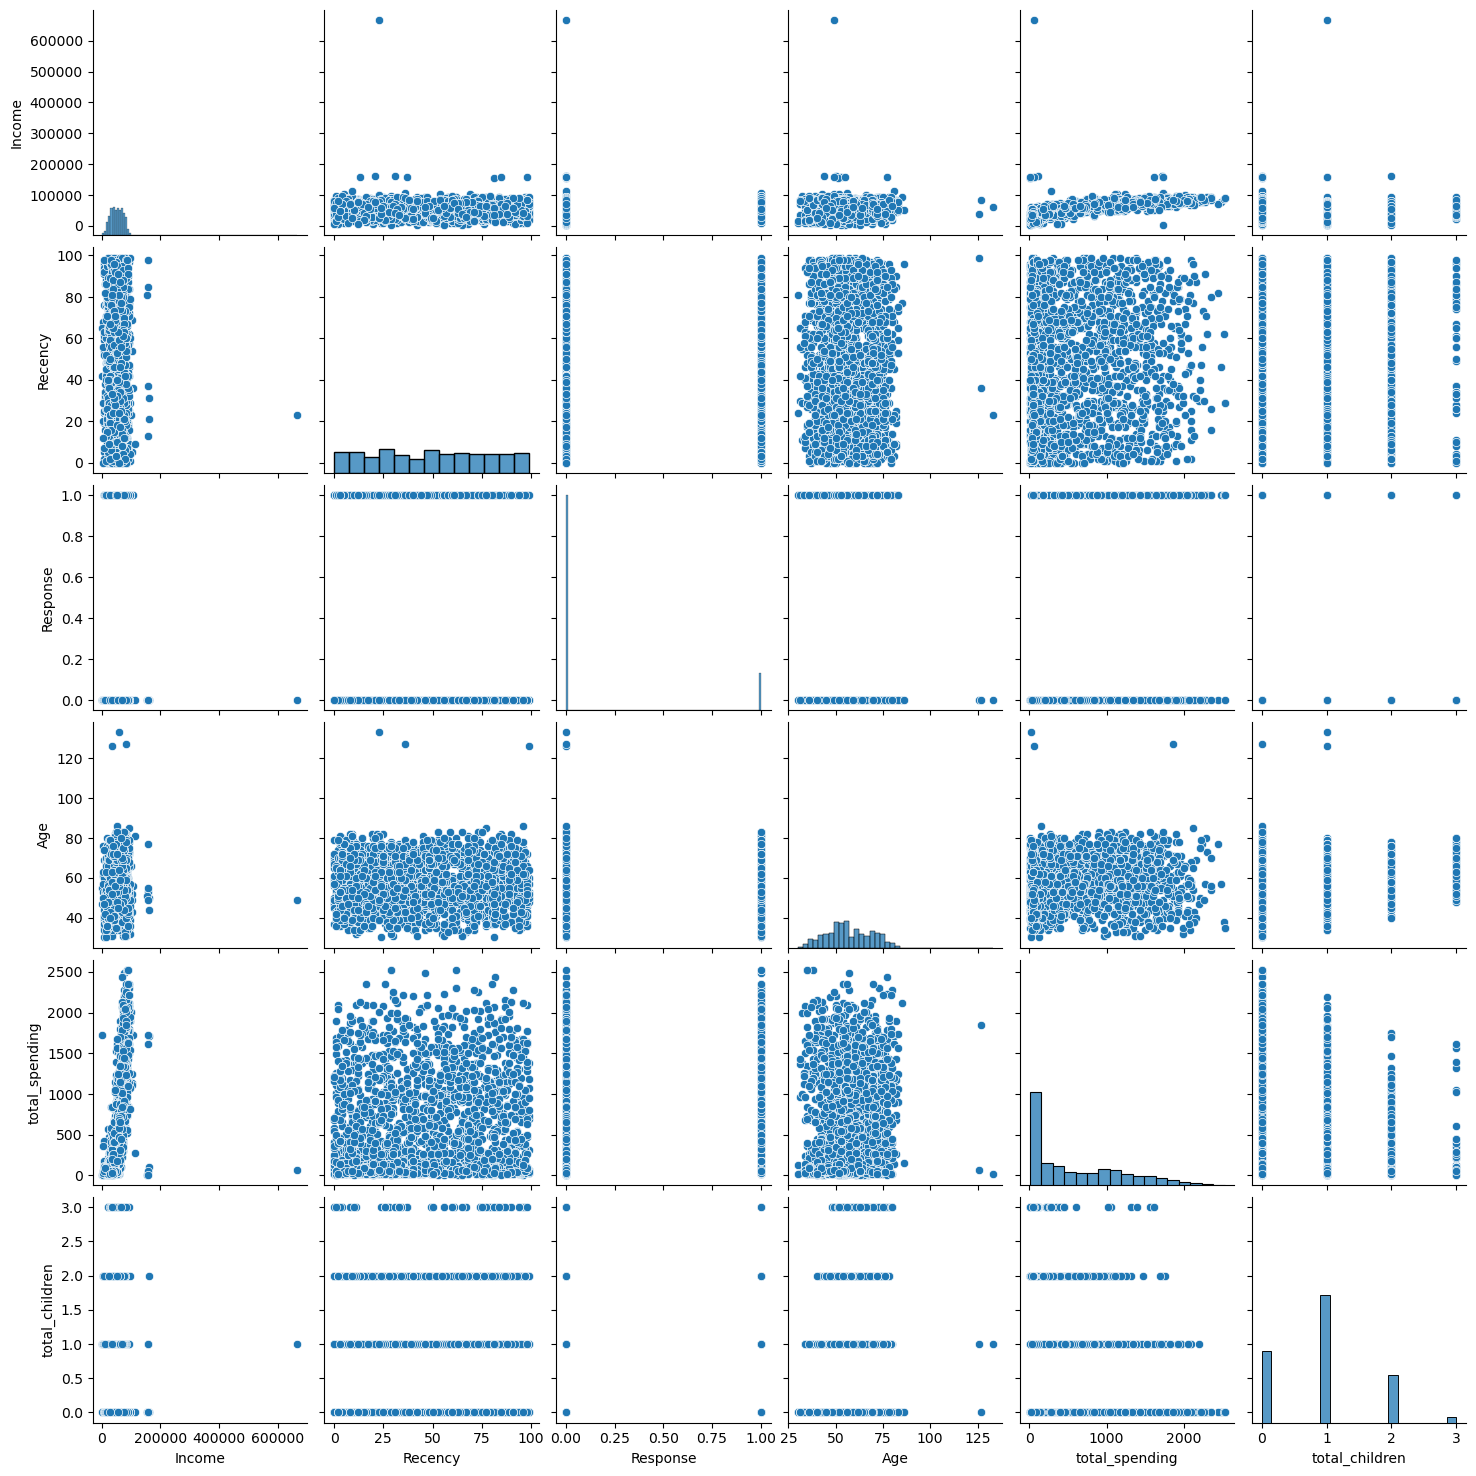

In [17]:
cols=["Income","Recency","Response","Age","total_spending","total_children"]
sns.pairplot(df_cleaned[cols])

In [20]:
df_cleaned= df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned= df_cleaned[(df_cleaned["Income"]<600000)]



### Heatmap


<Axes: >

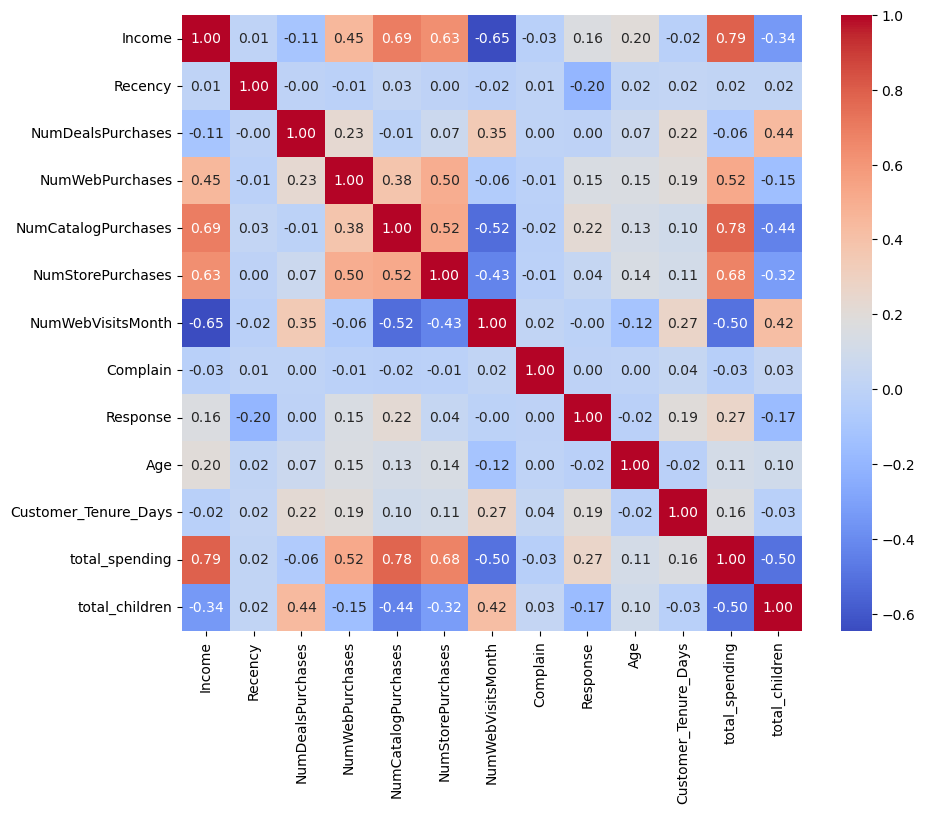

In [24]:
correlation_matrix = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

### Feature Encoding